# Subsetted (final working_df) cohort statistics and regression covariate correlations

In [1]:
import warnings
from arivale_data_interface import get_snapshot
import pandas as pd
import numpy as np
import scipy
import json

warnings.simplefilter("ignore")

#import the final master sleep_merged df and the features_dict

sleep_merged = pd.read_csv('../working_df/sleep_merged_sleep_meds_included_11_20_2025.csv', dtype={'public_client_id': object})

with open('../working_df/features_dict.json', 'r') as f:
    features_dict = json.load(f)

In [2]:
sleep_merged[features_dict['covariate_features']].describe()

,age,BMI_CALC,PC1,PC2,PC3
count,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000
mean,47.306725,28.013219,0.000873,-0.000177,-0.000891
std,11.690407,6.249191,0.013436,0.013371,0.012717
min,22.000000,17.138225,-0.052242,-0.022505,-0.022188
25%,39.000000,23.620626,0.004499,-0.002313,-0.004324
50%,48.000000,26.642434,0.006139,-0.001835,-0.003419
75%,56.000000,30.990308,0.006522,-0.000888,-0.002045
max,82.000000,59.727539,0.007332,0.115726,0.078654


In [3]:
sleep_merged.sex.value_counts()

sex
F    980
M    611
Name: count, dtype: int64

In [5]:
sleep_merged.sex.value_counts(normalize=True)

sex
F    0.615965
M    0.384035
Name: proportion, dtype: float64

## Correlation matrix

In [6]:
covariates_df = sleep_merged.copy()
covariates_df["sex"] = covariates_df.sex.map(lambda x: 0 if x == "M" else 1)

In [7]:
features_dict['sleep_features_log1p_resids']

['sleep_awakeDuration_log1p_resid',
 'sleep_awakeningsCount_log1p_resid',
 'sleep_efficiency_log1p_resid',
 'sleep_minutesAfterWakeup_log1p_resid',
 'sleep_minutesAsleep_log1p_resid',
 'sleep_minutesAwake_log1p_resid',
 'sleep_restlessDuration_log1p_resid',
 'sleep_timeInBed_log1p_resid',
 'sleep_awakeDuration_std_log1p_resid',
 'sleep_awakeningsCount_std_log1p_resid',
 'sleep_efficiency_std_log1p_resid',
 'sleep_minutesAfterWakeup_std_log1p_resid',
 'sleep_minutesAsleep_std_log1p_resid',
 'sleep_minutesAwake_std_log1p_resid',
 'sleep_restlessDuration_std_log1p_resid',
 'sleep_timeInBed_std_log1p_resid',
 'bedtime_int_log1p_resid',
 'bedtime_int_std_log1p_resid']

In [8]:
correlate_df = covariates_df[features_dict['sleep_features_log1p_resids'] + features_dict['covariate_features'] + ["activities_activityCalories_resid",
                                                                                                                   "activities_steps_resid",
                                                                                                                   "activities_floors_resid",
                                                                                                                   "any_mental_health_self_anytime_before",
                                                                                                                   "any_sleep_disorder_self_anytime_before",
                                                                                                                   "avg_stress"]]

correlate_df.fillna(correlate_df.median(), inplace=True)

In [9]:
correlate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1591 entries, 0 to 1590
Data columns (total 30 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   sleep_awakeDuration_log1p_resid           1591 non-null   float64
 1   sleep_awakeningsCount_log1p_resid         1591 non-null   float64
 2   sleep_efficiency_log1p_resid              1591 non-null   float64
 3   sleep_minutesAfterWakeup_log1p_resid      1591 non-null   float64
 4   sleep_minutesAsleep_log1p_resid           1591 non-null   float64
 5   sleep_minutesAwake_log1p_resid            1591 non-null   float64
 6   sleep_restlessDuration_log1p_resid        1591 non-null   float64
 7   sleep_timeInBed_log1p_resid               1591 non-null   float64
 8   sleep_awakeDuration_std_log1p_resid       1591 non-null   float64
 9   sleep_awakeningsCount_std_log1p_resid     1591 non-null   float64
 10  sleep_efficiency_std_log1p_resid    

In [10]:
from scipy.stats import spearmanr

corr_matrix, p_matrix = spearmanr(correlate_df)

corr_df = pd.DataFrame(corr_matrix, index=correlate_df.columns, columns=correlate_df.columns)
p_df = pd.DataFrame(p_matrix, index=correlate_df.columns, columns=correlate_df.columns)

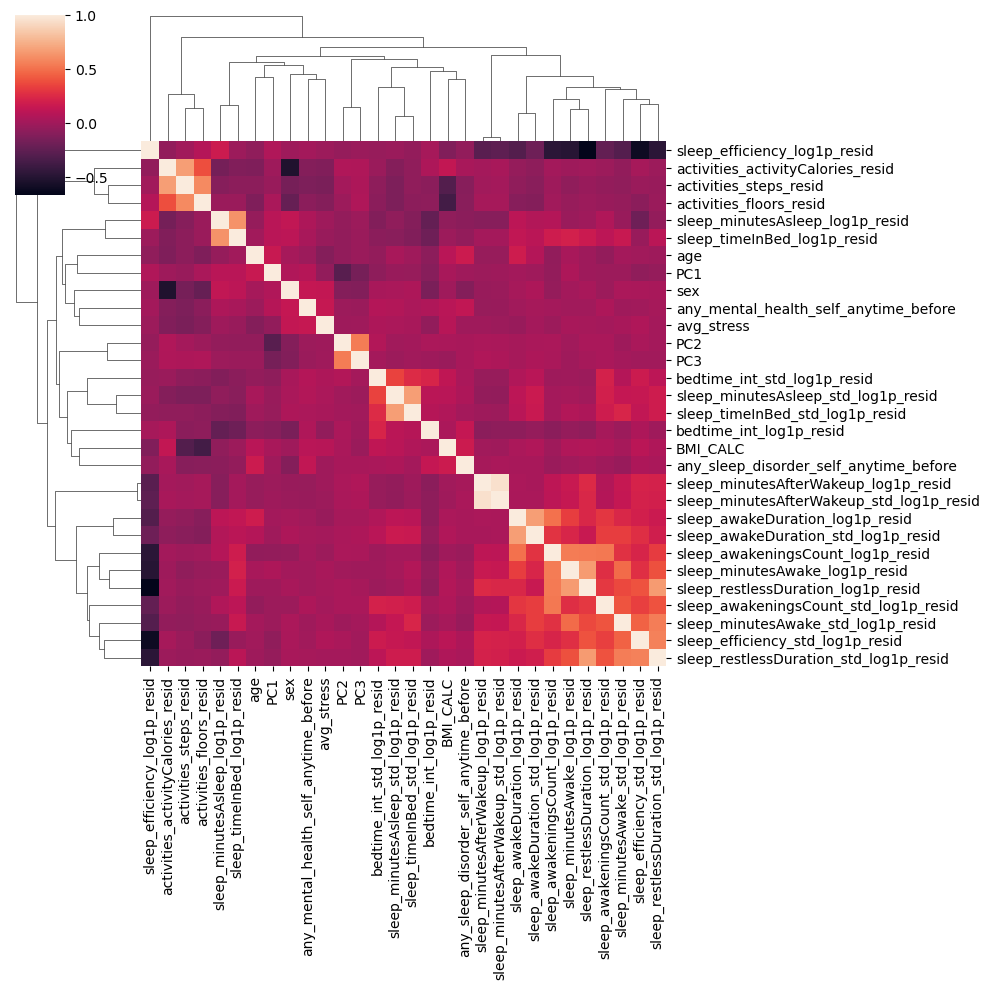

In [11]:
import seaborn as sns

cluster_grid = sns.clustermap(corr_df)

# Get the reordered indices from the clustermap
reordered_indices = cluster_grid.dendrogram_row.reordered_ind
reordered_columns = corr_df.columns[reordered_indices]

# Reorder the DataFrame
reordered_corr_matrix = corr_df.loc[reordered_columns, reordered_columns]
reordered_p_matrix = p_df.loc[reordered_columns, reordered_columns]

In [12]:
from statsmodels.stats.multitest import multipletests

# Convert the correlation matrix to long format
corr_long = reordered_corr_matrix.reset_index().melt(id_vars='index', var_name='variable', value_name='correlation')
corr_long.columns = ['x', 'y', 'correlation']


# Convert the p-value matrix to long format
p_long = reordered_p_matrix.reset_index().melt(id_vars='index', var_name='variable', value_name='p_value')
p_long.columns = ['x', 'y', 'p_value']
#p_long = p_long.groupby("x", as_index=False).apply(
#    lambda group: group.assign(q=multipletests(group['p_value'], method='fdr_bh')[1]))
#p_long["q_val_mark"] = p_long.q.map(lambda x: "*" if x < 0.05 else "")
p_long["p_val_mark"] = p_long.p_value.map(lambda x: "*" if x < 0.05 else "")

In [13]:
# What does the distribution of correlations NOT between sleep features look like
import re
abs(corr_long[(~corr_long.x.str.contains(r'sleep.*resid', regex=True)) & (~corr_long.y.str.contains(r'sleep.*resid', regex=True)) & (corr_long.correlation.round() != 1)].correlation).describe()

count    176.000000
mean       0.093017
std        0.088370
min        0.002645
25%        0.031579
50%        0.073182
75%        0.126577
max        0.526059
Name: correlation, dtype: float64

In [14]:
corr_p_long = pd.merge(corr_long, p_long, on=["x", "y"])

In [15]:
# Clean up the names:
label_map = {
    'sleep_minutesAsleep_log1p_resid': 'minutes_asleep',
    'sleep_timeInBed_log1p_resid': 'time_in_bed',
    'sleep_awakeningsCount_log1p_resid': 'awakenings_count',
    'sleep_minutesAfterWakeup_log1p_resid': 'minutes_after_wakeup',
    'sleep_minutesAwake_log1p_resid': 'minutes_awake',
    'sleep_awakeDuration_log1p_resid': 'awake_duration',
    'sleep_restlessDuration_log1p_resid': 'restless_duration',
    'sleep_minutesAsleep_std_log1p_resid': 'minutes_asleep_SD',
    'sleep_timeInBed_std_log1p_resid': 'time_in_bed_SD',
    'sleep_awakeningsCount_std_log1p_resid': 'awakenings_count_SD',
    'sleep_minutesAfterWakeup_std_log1p_resid': 'minutes_after_wakeup_SD',
    'sleep_minutesAwake_std_log1p_resid': 'minutes_awake_SD',
    'sleep_awakeDuration_std_log1p_resid': 'awake_duration_SD',
    'sleep_restlessDuration_std_log1p_resid': 'restless_duration_SD',
    'bedtime_int_log1p_resid': 'bedtime',
    'bedtime_int_std_log1p_resid': 'bedtime_SD',
    'sleep_efficiency_log1p_resid': 'sleep_efficiency',
    'sleep_efficiency_std_log1p_resid': 'sleep_efficiency_SD',
    # Activity rename
    "activities_activityCalories_resid": "activity_activeCalories",
    "activities_steps_resid": "activity_steps",
    "activities_floors_resid": "activity_floors",
    # Sleep/mental health disorder
    'any_mental_health_self_anytime_before': 'any_mental_illness',
    'any_sleep_disorder_self_anytime_before': 'any_sleep_disorder',
    'avg_stress': 'psychological_stress_(PSS)',
    'BMI_CALC': 'BMI'
}

In [16]:
corr_p_long.replace(label_map, inplace=True)

In [17]:
import altair as alt

cell_step = 15
font_size = 9

color_scale = alt.Scale(domain=[-1, 1], range=["#742881", "transparent", "#1B7939"])

feature_order = list(dict.fromkeys(corr_p_long["x"]))

base = (
    alt.Chart(corr_p_long)
    .transform_calculate(
        x_idx=f"indexof({feature_order}, datum.x)",
        y_idx=f"indexof({feature_order}, datum.y)"
    )
    # ✅ keep LOWER triangle (mask upper)
    .transform_filter("datum.y_idx >= datum.x_idx")
    .encode(
        x=alt.X("x:O", sort=feature_order, title=None,
                axis=alt.Axis(labelAngle=45, labelPadding=2, tickSize=0, domain=False)),
        y=alt.Y("y:O", sort=feature_order, title=None,
                axis=alt.Axis(labelPadding=2, tickSize=0, domain=False)),
        color=alt.Color("correlation:Q", scale=color_scale,
                        legend=alt.Legend(title="Spearman r", orient='top')),
        tooltip=["x", "y", "correlation", "p_value"],
    )
    .properties(
        width={"step": cell_step},
        height={"step": cell_step},
        title=""
    )
)

heat = base.mark_rect()
txt = base.mark_text(fontSize=font_size).encode(text="p_val_mark:N", color=alt.value("black"))

(heat + txt).configure_view(stroke=None)

alt.LayerChart(...)